In [1]:
from google_play_scraper import reviews, Sort, app
import pandas as pd

APP_ID = 'com.dreamplug.androidapp'  # CRED

result, _ = reviews(
    APP_ID,
    lang='en',
    country='in',
    sort=Sort.NEWEST,
    count=150000
)

df = pd.DataFrame(result)

# df.to_csv('cred_reviews_raw.csv', index=False)
print(f"Scraped {len(df)} reviews")
print(df.columns.tolist())

df['content']=df['content'].str.lower().str.strip()


Scraped 150000 reviews
['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']


In [2]:
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,fa2677c8-b63f-4aa3-82ab-f80a92a65847,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,good application for credit card bill payment,5,0,5.6.4.31,2026-02-25 12:01:42,None,NaT,5.6.4.31
1,239d63f7-9ea8-4d7b-9bfa-7fec2aca241f,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,good,5,0,5.5.9.4,2026-02-25 10:43:07,None,NaT,5.5.9.4
2,12b0e9b5-c598-4142-972c-3d501ac5a1c5,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"after all demanded access to my account, final...",1,0,5.6.4.31,2026-02-25 10:29:48,None,NaT,5.6.4.31
3,138c08be-f5b3-48f1-b51b-ec8d2c213aee,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,नारायण सिंह बादल सीहोर जिला रतलामतहसील,5,0,5.6.4.31,2026-02-25 09:47:02,None,NaT,5.6.4.31
4,6f7ade56-663c-4e34-a316-90a9270ec1fc,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,everything is ok. but my personal suggestion i...,4,0,5.6.3.8,2026-02-25 08:47:17,None,NaT,5.6.3.8
...,...,...,...,...,...,...,...,...,...,...,...
149995,fa2601a9-67c1-486b-9b8d-ed13b8e57ca1,thumpi duram,https://play-lh.googleusercontent.com/a-/ALV-U...,best app ever. interface is sexy.,5,0,3.1.4.8,2022-10-15 20:42:38,None,NaT,3.1.4.8
149996,ed1cc7aa-65f3-4091-826a-1dca91fa079c,Rohit bhimanna,https://play-lh.googleusercontent.com/a/ACg8oc...,the experience was too bad credit card payment...,1,0,3.1.4.8,2022-10-15 20:42:37,"\nHi Rohit, we always operate with integrity a...",2022-10-17 13:48:36,3.1.4.8
149997,f7bbb777-95fe-44be-a42c-ea1f9ef12652,Ashutosh Kumar,https://play-lh.googleusercontent.com/a/ACg8oc...,good,5,0,3.1.4.8,2022-10-15 20:40:11,None,NaT,3.1.4.8
149998,11c9d9c4-e90c-4779-b3bd-ec21dcb9c21f,Prashant Patil,https://play-lh.googleusercontent.com/a-/ALV-U...,the cred point game is totally fake. 27lac cre...,1,0,3.1.4.8,2022-10-15 20:35:41,"\nHi Prashant, we’re unhappy to see that you’r...",2022-10-19 16:52:11,3.1.4.8


In [3]:
df['at']=pd.to_datetime(df['at'],dayfirst=True)
df.dtypes

reviewId                        object
userName                        object
userImage                       object
content                         object
score                            int64
thumbsUpCount                    int64
reviewCreatedVersion            object
at                      datetime64[ns]
replyContent                    object
repliedAt               datetime64[ns]
appVersion                      object
dtype: object

In [4]:
themes = {
    'rewards_devaluation': [
        'reward', 'coin', 'cashback', 'points', 'redeem',
        'worthless', 'useless', 'devalued', 'reduced', 'less coins'
    ],
    'app_performance': [
        'crash', 'bug', 'freeze', 'slow', 'lag', 'loading',
        'stuck', 'error', 'broken', 'not working', 'glitch'
    ],
    'customer_support': [
        'support', 'customer care', 'response', 'helpless',
        'no reply', 'worst service', 'unresponsive', 'refund'
    ],
    'payment_issues': [
        'payment', 'transaction', 'failed', 'deducted',
        'not credited', 'bill', 'emi', 'credit card'
    ],
    'ui_ux': [
        'interface', 'design', 'confusing', 'difficult',
        'navigation', 'ui', 'ux', 'complicated', 'cluttered'
    ],
    'loan_issues': [
        'loan', 'interest', 'eligibility', 'rejected',
        'approval', 'borrow', 'repay'
    ],
    'trust_privacy': [
        'spam', 'privacy', 'data', 'scam', 'fraud',
        'misleading', 'fake', 'trust', 'suspicious'
    ],
    'feature_request': [
        'feature', 'option', 'wish', 'would be great',
        'please add', 'missing', 'need', 'want'
    ]
}

def tag_theme(review):
    for theme, keywords in themes.items():
        if any(kw in review for kw in keywords):
            return theme
    return 'other'

df['theme'] = df['content'].apply(tag_theme)


In [5]:
keywords = [
    'reward', 'rewards', 'coin', 'coins', 'cashback', 'cash back',
    'redeem', 'redemption', 'points', 'gems', 'store', 'cred store',
    'search', 'discover', 'browse', 'find', 'explore'
]

In [6]:
mask=df['content'].str.lower().str.contains('|'.join(keywords), na=False)
df_filtered=df[mask]
df_filtered.sort_values(by='score',ascending=False)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,theme
149962,1ac79043-e37e-4d6c-8437-71e00a1371a0,Kosygin Leishangthem,https://play-lh.googleusercontent.com/a-/ALV-U...,easy & heavy cash back,5,0,3.1.4.8,2022-10-16 02:46:35,None,NaT,3.1.4.8,other
76647,22bf1764-fded-446d-a7bd-b0406d4057ee,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,it's very fast and trustable app for credit ca...,5,0,None,2024-03-14 15:52:10,None,NaT,None,rewards_devaluation
76219,f2d3bbee-a069-4462-8ae4-af381e7a17de,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,good service hai cashback,5,0,4.2.9.6,2024-03-18 08:25:13,None,NaT,4.2.9.6,rewards_devaluation
76243,5aaeb0c7-7c1e-4bca-a496-80f53dcdacbd,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,very beautiful app. credit card gift 🎁 reward ...,5,0,4.2.9.6,2024-03-17 23:15:43,None,NaT,4.2.9.6,rewards_devaluation
76269,77aa703d-26b6-41d8-8354-f71e6f99ed57,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,nice app for pay your credit card payment supe...,5,0,4.2.9.6,2024-03-17 19:58:13,None,NaT,4.2.9.6,rewards_devaluation
...,...,...,...,...,...,...,...,...,...,...,...,...
149970,4bae415f-f772-41bd-ad79-4e8f1006f402,ARIJIT IPO KING,https://play-lh.googleusercontent.com/a-/ALV-U...,worst apps day by day ...... don't trap their ...,1,0,None,2022-10-16 00:10:30,None,NaT,None,rewards_devaluation
149961,c68eb7e8-4bc7-4727-b1da-a41d8603c64d,Udgrand Dev,https://play-lh.googleusercontent.com/a-/ALV-U...,i'm using cred app almost 3+ years but it is w...,1,0,3.0.2.2,2022-10-16 02:48:31,"\nHi Udgrand, we understand that rewards are a...",2022-10-17 13:44:42,3.0.2.2,rewards_devaluation
149956,8dfa1ad9-c591-461a-af92-d7567e288108,thisIs noOne,https://play-lh.googleusercontent.com/a/ACg8oc...,what kind of stupid app is this which doesn't ...,1,0,3.1.4.8,2022-10-16 06:50:50,"\nHi, thank you for sharing your thoughts on t...",2022-10-17 18:18:06,3.1.4.8,feature_request
149948,a3c775ac-ddf2-410b-a439-1e5bb1f3454d,RAJ,https://play-lh.googleusercontent.com/a-/ALV-U...,waste app. one can get more offers if paid wit...,1,0,3.1.4.8,2022-10-16 09:59:17,"\nHi Raj, we understand that you are not happy...",2022-10-17 18:13:09,3.1.4.8,rewards_devaluation


In [7]:
df_filtered[df_filtered['score'] < 3].groupby('appVersion').size().reset_index(name='review_count').sort_values('review_count', ascending=False).query('review_count>30').head(10)

,appVersion,review_count
52,3.2.3.18,385
57,4.0.1.6,237
41,3.1.5.7,229
47,3.2.0.11,190
46,3.1.9.4,161
90,4.4.8.1,145
86,4.4.2.4,128
58,4.0.2.2,116
42,3.1.6.9,111
87,4.4.3.6,111


In [8]:
df_filtered.appVersion.describe()

count        11149
unique         181
top       3.2.3.18
freq           574
Name: appVersion, dtype: object

In [9]:
df[(df['theme']=='rewards_devaluation')&(df['at']>"2025-01-01")]

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,theme
2,12b0e9b5-c598-4142-972c-3d501ac5a1c5,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"after all demanded access to my account, final...",1,0,5.6.4.31,2026-02-25 10:29:48,None,NaT,5.6.4.31,rewards_devaluation
12,9fcc678d-7a2d-4a89-9013-bdde8f778c7b,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,always missing cashback especially if you payi...,1,0,5.6.4.31,2026-02-24 21:43:12,"\nHi Kunal, it’s unfortunate to hear about you...",2026-02-25 10:02:44,5.6.4.31,rewards_devaluation
16,bac0e351-9ee4-48ee-9921-41cbd0676303,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"absolutely terrible app, don't use it at all. ...",1,0,5.6.4.31,2026-02-24 20:46:03,"\nHi Sandip, it’s unfortunate to hear about yo...",2026-02-25 10:08:15,5.6.4.31,rewards_devaluation
17,c8c9c788-7a94-4c79-833f-7c41ac90db7d,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,no reward bad experience,1,0,5.6.3.3,2026-02-24 20:40:23,"\nHi Bhikaji, your feedback is important to us...",2026-02-25 10:16:52,5.6.3.3,rewards_devaluation
18,c6fcfd5f-74cf-4b15-90b7-dbf6ff313ac4,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,reward better,5,0,5.5.0.11,2026-02-24 20:38:35,None,NaT,5.5.0.11,rewards_devaluation
...,...,...,...,...,...,...,...,...,...,...,...,...
38464,fdda570b-6aad-486a-986a-f01b0552963b,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,in starting day this app se best but now less ...,5,0,4.8.6.8,2025-01-02 11:56:07,None,NaT,4.8.6.8,rewards_devaluation
38522,40e22ea6-e8ff-4765-be16-5369babcc6df,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,i got good rewards,5,0,4.2.3.9,2025-01-01 20:27:06,None,NaT,4.2.3.9,rewards_devaluation
38573,ffcf64f1-1b31-4346-b2a6-16f4ac9a0f5a,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,good aap and confirm cashback,5,0,4.8.4.1,2025-01-01 15:04:58,None,NaT,4.8.4.1,rewards_devaluation
38576,8cce8b65-f49b-47ba-802f-947c5bfe126e,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,i'm extremely disappointed with cred's cashbac...,1,0,4.8.6.8,2025-01-01 14:25:48,"\nHi Mukesh, we’re unhappy to see that you’re ...",2025-01-04 10:49:14,4.8.6.8,rewards_devaluation


In [10]:
print(f"Total reviews: {len(df)}")
print(f"Date range: {df['at'].min()} to {df['at'].max()}")
print(f"\nUnique app versions: {df['appVersion'].nunique()}")
print("\nTop 15 versions by review count:")
print(df['appVersion'].value_counts().head(15))

Total reviews: 150000
Date range: 2022-10-15 20:35:23 to 2026-02-25 12:01:42

Unique app versions: 233

Top 15 versions by review count:
appVersion
3.1.5.7     5588
3.2.3.18    4333
3.2.0.11    4106
4.4.8.1     3591
4.4.3.6     3166
4.0.1.6     3113
4.4.2.4     2996
3.1.9.4     2862
4.1.6.11    2734
4.0.4.4     2683
4.2.5.5     2649
4.1.9.8     2454
4.1.7.9     2452
4.2.8.1     2407
4.0.2.2     2369
Name: count, dtype: int64


In [27]:
# Only keep version which 100+ reviews 
valid_versions = (df['appVersion'].value_counts()[lambda x: x >= 100].index)

df_valid = df[df['appVersion'].isin(valid_versions)].copy()
print(f"reviews in valid versions: {len(df_valid)}")
print(f"versions retained: {len(valid_versions)}")

reviews in valid versions: 134552
versions retained: 110


In [12]:
pain_points = (df_valid[df_valid['score'] < 3].groupby('theme').agg(
        review_count=('content', 'count'),
        avg_rating=('score', 'mean'),
        total_thumbs_up=('thumbsUpCount', 'sum'),
        avg_thumbs_up=('thumbsUpCount', 'mean')
    ).sort_values('total_thumbs_up', ascending=False).reset_index()
)
print(pain_points)

                 theme  review_count  avg_rating  total_thumbs_up  \
0  rewards_devaluation          5715    1.137183            22619   
1     customer_support          3929    1.053194            10932   
2       payment_issues          3828    1.105799             8247   
3      app_performance          1891    1.123744             2994   
4                other          5668    1.121912             1798   
5        trust_privacy           903    1.031008              598   
6                ui_ux           463    1.231102              476   
7      feature_request           531    1.158192              411   
8          loan_issues           296    1.104730              143   

   avg_thumbs_up  
0       3.957830  
1       2.782387  
2       2.154389  
3       1.583289  
4       0.317219  
5       0.662237  
6       1.028078  
7       0.774011  
8       0.483108  


In [26]:


theme_spread = (df_valid[df_valid['score'] < 3].groupby(['theme', 'appVersion'])
    .size().reset_index(name='count'))

for theme in theme_spread['theme'].unique():
    subset = theme_spread[theme_spread['theme'] == theme]
    total = subset['count'].sum()
    top2 = subset.nlargest(2, 'count')['count'].sum()
    concentration = top2 / total * 100
    
    label = 'version bug' if concentration > 60 else ' singkle version problem'
    print(f"{theme:<25} {label} — top 2 versions = {concentration:.0f}% of complaints")

app_performance            singkle version problem — top 2 versions = 8% of complaints
customer_support           singkle version problem — top 2 versions = 10% of complaints
feature_request            singkle version problem — top 2 versions = 8% of complaints
loan_issues                singkle version problem — top 2 versions = 8% of complaints
other                      singkle version problem — top 2 versions = 8% of complaints
payment_issues             singkle version problem — top 2 versions = 11% of complaints
rewards_devaluation        singkle version problem — top 2 versions = 10% of complaints
trust_privacy              singkle version problem — top 2 versions = 7% of complaints
ui_ux                      singkle version problem — top 2 versions = 11% of complaints


In [14]:
top_complaints = (
    df_valid[
        (df_valid['theme'] == 'rewards_devaluation') &
        (df_valid['score'] < 3)
    ]
    .sort_values('thumbsUpCount', ascending=False)
    [['content', 'score', 'thumbsUpCount', 'at', 'appVersion']]
    .head(10)
)


print("TOP 10 MOST UPVOTED REWARDS COMPLAINTS")

for _, row in top_complaints.iterrows():
    print(f"\n[{row['thumbsUpCount']} thumbs up | {row['score']} star| {str(row['at'])[:10]}]")
    print(f"  {str(row['content'])[:200]}")

TOP 10 MOST UPVOTED REWARDS COMPLAINTS

[2603 thumbs up | 1 star| 2025-09-12]
  the support system in cred is absolutely useless. when i go to the rewards section, the "contact now" option is given for any different questions, but after that, no option to report your issue is vis

[1017 thumbs up | 1 star| 2023-07-27]
  such a confusing app. not able to find products, credit card payment options, products are less and expensive.... they keep on changing ui and then it's difficult for the user to adapt the change. als

[715 thumbs up | 1 star| 2024-04-07]
  the app provides a lot of offers and vouchers which are nothing but scam to make you use the app and then regret later. even the payments of credit card is not rewarding anymore, just useless vouchers

[651 thumbs up | 2 star| 2024-02-14]
  great app to pay cc bills. cons: you get cred points, which are useless. the spins and raffles are rigged to make you lose points, giving you a false sense of utilizing the points and to top the o

In [ ]:

overall_avg = df_valid['score'].mean()
rewards_all_avg = df_valid[df_valid['theme']=='rewards_devaluation']['score'].mean()
pct_negative_rewards = (
    len(df_valid[(df_valid['theme']=='rewards_devaluation') & (df_valid['score']<3)]) /
    len(df_valid[df_valid['theme']=='rewards_devaluation']) * 100
)


print(f"Overall avg rating: {overall_avg:.2f}")
print(f"Rewards theme avg rating: {rewards_all_avg:.2f}")
print(f"% of rewards reviews that are negative: {pct_negative_rewards:.1f}%")


Overall avg rating: 4.20
Rewards theme avg rating: 2.48
% of rewards reviews that are negative: 59.8%


In [29]:

pain_points['review_count_norm'] = (
    pain_points['review_count'] - pain_points['review_count'].min()
) / (pain_points['review_count'].max() - pain_points['review_count'].min())

pain_points['thumbs_up_norm'] = (
    pain_points['total_thumbs_up'] - pain_points['total_thumbs_up'].min()
) / (pain_points['total_thumbs_up'].max() - pain_points['total_thumbs_up'].min())

pain_points['pain_index'] = (
    pain_points['review_count_norm'] * 0.4 +
    pain_points['thumbs_up_norm'] * 0.6
).round(3)



print("Which theme should be fixed  — Cred App (150000 Reviews)")

print(pain_points.to_string(index=False))
print("total reviews considered",df.content.count())
print("actual paintpoits data considered",pain_points.review_count.sum())

Which theme should be fixed  — Cred App (150000 Reviews)
              theme  review_count  avg_rating  total_thumbs_up  avg_thumbs_up  review_count_norm  thumbs_up_norm  pain_index
rewards_devaluation          5715    1.137183            22619       3.957830           1.000000        1.000000       1.000
   customer_support          3929    1.053194            10932       2.782387           0.670419        0.480023       0.556
     payment_issues          3828    1.105799             8247       2.154389           0.651781        0.360562       0.477
    app_performance          1891    1.123744             2994       1.583289           0.294335        0.126846       0.194
              other          5668    1.121912             1798       0.317219           0.991327        0.073634       0.441
      trust_privacy           903    1.031008              598       0.662237           0.112013        0.020244       0.057
              ui_ux           463    1.231102              476      

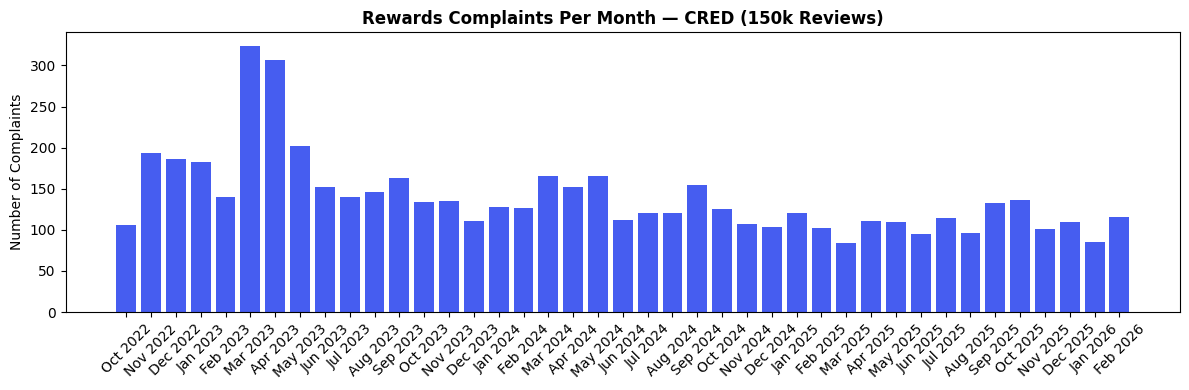

In [24]:
import matplotlib.pyplot as plt

rewards_trend = (
    df_valid[
        (df_valid['theme'] == 'rewards_devaluation') &
        (df_valid['score'] < 3)
    ]
    .assign(
        year=df_valid['at'].dt.year,
        month=df_valid['at'].dt.month
    )
    .groupby(['year', 'month'])
    .size()
    .reset_index(name='complaint_count')
    .sort_values(['year', 'month'])
)

rewards_trend['label'] = (
    rewards_trend['month']
    .apply(lambda x: pd.Timestamp(2000, x, 1).strftime('%b'))
    + ' ' +
    rewards_trend['year'].astype(str)
)

plt.figure(figsize=(12, 4))
plt.bar(
    rewards_trend['label'],
    rewards_trend['complaint_count'],
    color="#1330ecc8"
)
plt.title(
    'Rewards Complaints Per Month — CRED (150k Reviews)',
    fontsize=12, fontweight='bold'
)
plt.xticks(rotation=45)
plt.ylabel('Number of Complaints')
plt.tight_layout()
plt.savefig('rewards_trend.png', dpi=150)
plt.show()

In [18]:
df_valid[[
    'reviewId', 'score', 'thumbsUpCount', 'at',
    'appVersion', 'theme', 'content'
]].to_csv('cred_powerbi.csv', index=False)

pain_points[pain_points['theme'] != 'other'].to_csv(
    'cred_pain_index.csv', index=False
)

In [31]:
df_valid.groupby('theme').agg(
        review_count=('content', 'count'),
        avg_rating=('score', 'mean'),
        total_thumbs_up=('thumbsUpCount', 'sum'),
        avg_thumbs_up=('thumbsUpCount', 'mean'),
        neg_reviews=('score',lambda x:(x<3).sum())
    ).sort_values('total_thumbs_up', ascending=False).reset_index()

,theme,review_count,avg_rating,total_thumbs_up,avg_thumbs_up,neg_reviews
0,rewards_devaluation,9559,2.480490,42226,4.417408,5715
1,payment_issues,10538,3.417252,19771,1.876162,3828
2,customer_support,5396,1.999444,15743,2.917532,3929
3,app_performance,2657,1.983440,5426,2.042153,1891
4,other,101840,4.682129,2767,0.027170,5668
5,ui_ux,1494,3.561580,1289,0.862784,463
6,loan_issues,554,2.752708,1010,1.823105,296
7,feature_request,1411,3.183558,1000,0.708717,531
8,trust_privacy,1103,1.664551,688,0.623753,903
